Forecasting (ECC) PV with LSTM + Open-Meteo
- Uses PV_TotalProduction_kW at 15-min
- Pulls weather from Open-Meteo 
- Time-based split: last TEST_DAYS as test
- One-step ahead LSTM with "future weather for next step" as extra input
- Multi-step forecast via recursive rollout using weather forecast/historical weather

A hybrid LSTM-based photovoltaic power forecasting model with exogenous meteorological inputs from Open-Meteo. The model performs one-step-ahead prediction at 15-minute resolution and is deployed in recursive mode for 24-hour ahead forecasting. It combines historical PV production, weather variables, and cyclical time features.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)

TensorFlow: 2.14.0


In [16]:
DATA_DIR = Path("/Users/giannispapias/Desktop/TEF EV 2/ECC2/Data")
MASTER_CSV = DATA_DIR / "ECC_master_PV_EMOB1_EMOB2_15min.csv"

df = pd.read_csv(MASTER_CSV)
df["Started at"] = pd.to_datetime(df["Started at"], utc=True, errors="coerce")
df = df.dropna(subset=["Started at"]).sort_values("Started at")

In [17]:
pv = df[["Started at", "PV_TotalProduction_kW"]].copy()
pv = pv.dropna(subset=["PV_TotalProduction_kW"]).rename(columns={"PV_TotalProduction_kW": "pv_kw"})
pv = pv.sort_values("Started at")

print("PV coverage:", pv["Started at"].min(), "->", pv["Started at"].max(), "rows:", len(pv))

PV coverage: 2023-10-11 22:00:00+00:00 -> 2026-01-18 22:45:00+00:00 rows: 79684


In [ ]:
LAT = 49.70673
LON = 6.48714

WEATHER_VARS = [
    "shortwave_radiation",      # W/m²
    "direct_radiation",         # W/m²
    "diffuse_radiation",        # W/m²
    "cloud_cover",              # %
    "temperature_2m",           # °C
    "wind_speed_10m",           # m/s
]

def _openmeteo_request(url, params, timeout=60):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

def fetch_openmeteo_archive_15min(lat, lon, start_dt, end_dt, variables, tz="UTC"):
    """
    Try Open-Meteo Archive with minutely_15.
    If it fails or returns no minutely_15, return None.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": pd.to_datetime(start_dt).date().isoformat(),
        "end_date": pd.to_datetime(end_dt).date().isoformat(),
        "timezone": tz,
        "minutely_15": ",".join(variables),
    }
    try:
        js = _openmeteo_request(url, params)
        if "minutely_15" not in js or "time" not in js["minutely_15"]:
            return None
        m = js["minutely_15"]
        out = pd.DataFrame({"time": pd.to_datetime(m["time"], utc=True)})
        for v in variables:
            if v in m:
                out[v] = m[v]
            else:
                out[v] = np.nan
        out = out.set_index("time").sort_index()
        return out
    except Exception as e:
        print("minutely_15 archive failed -> fallback to hourly. Reason:", repr(e))
        return None

def fetch_openmeteo_archive_hourly(lat, lon, start_dt, end_dt, variables, tz="UTC"):
    """
    Open-Meteo Archive hourly, then resample/interpolate to 15-min.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": pd.to_datetime(start_dt).date().isoformat(),
        "end_date": pd.to_datetime(end_dt).date().isoformat(),
        "timezone": tz,
        "hourly": ",".join(variables),
    }
    js = _openmeteo_request(url, params)
    h = js["hourly"]
    out = pd.DataFrame({"time": pd.to_datetime(h["time"], utc=True)})
    for v in variables:
        out[v] = h.get(v, [np.nan]*len(out))
    out = out.set_index("time").sort_index()

    out_15 = out.resample("15min").interpolate("time")
    return out_15

def get_weather_15min(lat, lon, start_dt, end_dt, variables, tz="UTC"):
    """
    Returns weather at 15-min resolution in UTC index.
    Prefer minutely_15, fallback to hourly->15min.
    """
    w15 = fetch_openmeteo_archive_15min(lat, lon, start_dt, end_dt, variables, tz=tz)
    if w15 is not None:
        w15 = w15.resample("15min").mean()
        return w15
    return fetch_openmeteo_archive_hourly(lat, lon, start_dt, end_dt, variables, tz=tz)

In [19]:
start_dt = pv["Started at"].min()
end_dt   = pv["Started at"].max()

weather = get_weather_15min(LAT, LON, start_dt, end_dt, WEATHER_VARS, tz="UTC")

pv_idx = pv.set_index("Started at").sort_index()
data = pv_idx.join(weather, how="left")

data[WEATHER_VARS] = data[WEATHER_VARS].interpolate("time").ffill().bfill()

data["pv_kw"] = data["pv_kw"].clip(lower=0)

print("Merged rows:", len(data), "| Missing pv:", data["pv_kw"].isna().sum())

Merged rows: 79684 | Missing pv: 0


In [27]:
TEST_DAYS = 90  
split_ts = data.index.max() - pd.Timedelta(days=TEST_DAYS)

train = data[data.index < split_ts].copy()
test  = data[data.index >= split_ts].copy()

print("Train:", train.index.min(), "->", train.index.max(), "rows:", len(train))
print("Test :", test.index.min(),  "->", test.index.max(),  "rows:", len(test))

Train: 2023-10-11 22:00:00+00:00 -> 2025-10-20 22:30:00+00:00 rows: 71043
Test : 2025-10-20 22:45:00+00:00 -> 2026-01-18 22:45:00+00:00 rows: 8641


In [28]:
def add_time_features(df_):
    df_ = df_.copy()
    t = df_.index

    minutes = t.hour * 60 + t.minute
    df_["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
    df_["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))

    doy = t.dayofyear.values
    df_["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df_["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    return df_

train_fe = add_time_features(train)
test_fe  = add_time_features(test)

TIME_FEATS = ["tod_sin","tod_cos","doy_sin","doy_cos"]

SEQ_FEATURES = ["pv_kw"] + WEATHER_VARS + TIME_FEATS  
NEXT_WEATHER = WEATHER_VARS + TIME_FEATS              

scaler_seq = MinMaxScaler()
scaler_next = MinMaxScaler()
scaler_y = MinMaxScaler()

train_seq_scaled  = scaler_seq.fit_transform(train_fe[SEQ_FEATURES])
train_next_scaled = scaler_next.fit_transform(train_fe[NEXT_WEATHER])
train_y_scaled    = scaler_y.fit_transform(train_fe[["pv_kw"]])

test_seq_scaled   = scaler_seq.transform(test_fe[SEQ_FEATURES])
test_next_scaled  = scaler_next.transform(test_fe[NEXT_WEATHER])
test_y_scaled     = scaler_y.transform(test_fe[["pv_kw"]])

In [13]:
LOOKBACK = 96   
HORIZON  = 96   

def make_one_step_dataset(seq_scaled, next_scaled, y_scaled, lookback):
    """
    Builds:
      X_seq:  (N, lookback, n_seq_features)
      X_next: (N, n_next_features)
      y:      (N, 1)  -> pv at t+1
    Indexing:
      window ends at t, target is t+1
    """
    X_seq, X_next, y = [], [], []
    n = len(seq_scaled)
    for t in range(lookback, n-1):
        X_seq.append(seq_scaled[t-lookback:t, :])
        X_next.append(next_scaled[t+1, :])   
        y.append(y_scaled[t+1, :])           
    return np.array(X_seq), np.array(X_next), np.array(y)

Xtr_seq, Xtr_next, ytr = make_one_step_dataset(train_seq_scaled, train_next_scaled, train_y_scaled, LOOKBACK)
Xte_seq, Xte_next, yte = make_one_step_dataset(test_seq_scaled,  test_next_scaled,  test_y_scaled,  LOOKBACK)

print("Train samples:", Xtr_seq.shape, Xtr_next.shape, ytr.shape)
print("Test  samples:", Xte_seq.shape, Xte_next.shape, yte.shape)

Train samples: (70946, 96, 11) (70946, 10) (70946, 1)
Test  samples: (8544, 96, 11) (8544, 10) (8544, 1)


In [10]:
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

n_seq = Xtr_seq.shape[-1]
n_next = Xtr_next.shape[-1]

# Model 
inp_seq = layers.Input(shape=(LOOKBACK, n_seq), name="seq_input")
x = layers.LSTM(128, return_sequences=True)(inp_seq)
x = layers.BatchNormalization()(x)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

inp_next = layers.Input(shape=(n_next,), name="next_input")
z = layers.Dense(64, activation="relu")(inp_next)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.2)(z)

h = layers.Concatenate()([x, z])
h = layers.Dense(128, activation="relu")(h)
h = layers.BatchNormalization()(h)
h = layers.Dropout(0.3)(h)
h = layers.Dense(64, activation="relu")(h)
out = layers.Dense(1, name="pv_next")(h)

model = models.Model([inp_seq, inp_next], out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

model.summary()

es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)

hist = model.fit(
    {"seq_input": Xtr_seq, "next_input": Xtr_next},
    ytr,
    validation_split=0.15,
    epochs=60,
    batch_size=256,
    callbacks=[es, rlr],
    verbose=1
)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 seq_input (InputLayer)      [(None, 96, 11)]             0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 96, 128)              71680     ['seq_input[0][0]']           
                                                                                                  
 batch_normalization (Batch  (None, 96, 128)              512       ['lstm[0][0]']                
 Normalization)                                                                                   
                                                                                                  
 next_input (InputLayer)     [(None, 10)]                 0         []                        

In [11]:
yhat_scaled = model.predict({"seq_input": Xte_seq, "next_input": Xte_next}, verbose=0)
yhat = scaler_y.inverse_transform(yhat_scaled)
ytrue = scaler_y.inverse_transform(yte)

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(ytrue, yhat)

mse  = mean_squared_error(ytrue, yhat)   
rmse = np.sqrt(mse)

r2 = r2_score(ytrue, yhat)

print(f"One-step Test MAE : {mae:.3f} kW")
print(f"One-step Test RMSE: {rmse:.3f} kW")
print(f"One-step Test R²  : {r2:.4f}")

peak = max(float(np.max(ytrue)), 1e-6)
nmae = mae / peak
print(f"One-step Test nMAE: {nmae:.4f} (MAE / max PV)")

One-step Test MAE : 6.274 kW
One-step Test RMSE: 14.210 kW
One-step Test R²  : 0.8812
One-step Test nMAE: 0.0179 (MAE / max PV)


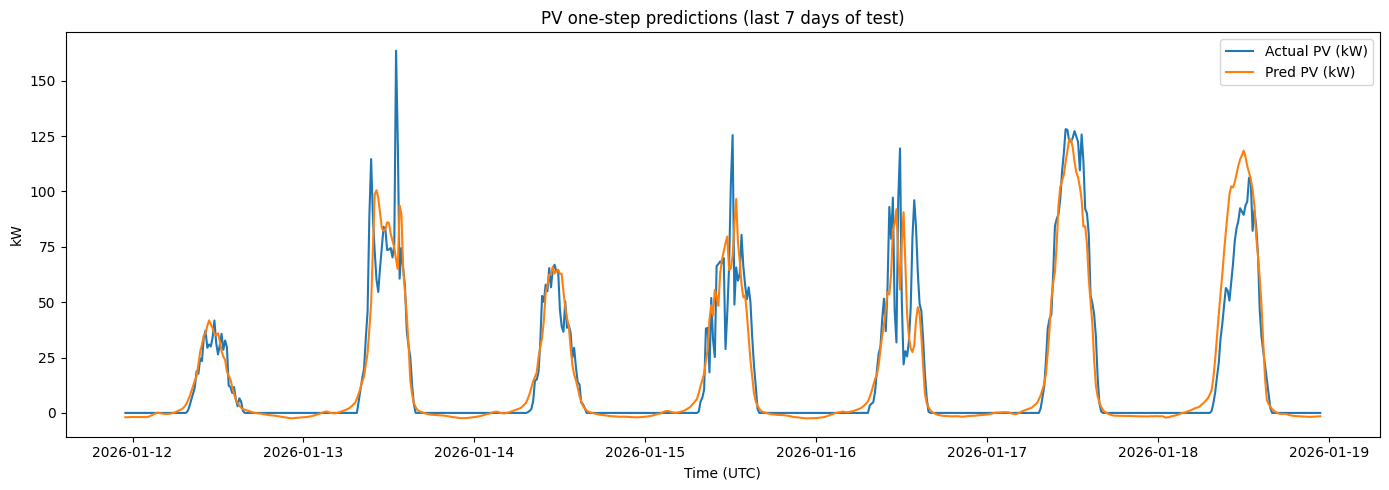

In [13]:
test_index = test_fe.index

pred_idx = test_index[LOOKBACK+1:]  
plot_n = 7*96

plt.figure(figsize=(14,5))
plt.plot(pred_idx[-plot_n:], ytrue[-plot_n:], label="Actual PV (kW)")
plt.plot(pred_idx[-plot_n:], yhat[-plot_n:], label="Pred PV (kW)")
plt.title("PV one-step predictions (last 7 days of test)")
plt.xlabel("Time (UTC)")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Multi-step (24h) forecast via recursive rollout

def recursive_forecast_24h(model, full_df_fe, start_time, lookback=96, horizon=96):
    if start_time not in full_df_fe.index:
        raise ValueError("start_time must be an existing timestamp in the dataframe index.")

    idx = full_df_fe.index
    start_pos = idx.get_loc(start_time)

    if start_pos < lookback:
        raise ValueError("Not enough history before start_time for the chosen lookback.")

    seq_scaled = scaler_seq.transform(full_df_fe[SEQ_FEATURES])
    next_scaled = scaler_next.transform(full_df_fe[NEXT_WEATHER])

    preds_scaled = []

    for step in range(1, horizon+1):
        t = start_pos + step - 1 

        X_seq = seq_scaled[t-lookback+1:t+1, :]  
        X_seq = X_seq.reshape(1, lookback, -1)

        X_next = next_scaled[t+1, :].reshape(1, -1)

        y_next_scaled = model.predict({"seq_input": X_seq, "next_input": X_next}, verbose=0)[0, 0]
        preds_scaled.append(y_next_scaled)

        seq_scaled[t+1, 0] = y_next_scaled

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds_kw = scaler_y.inverse_transform(preds_scaled).flatten()

    forecast_times = idx[start_pos+1:start_pos+1+horizon]
    return pd.DataFrame({"time": forecast_times, "pv_forecast_kw": preds_kw}).set_index("time")

In [15]:
full_fe = add_time_features(data.copy())
full_fe[WEATHER_VARS] = full_fe[WEATHER_VARS].interpolate("time").ffill().bfill()

example_start = test_fe.index[LOOKBACK + 200]  
fc = recursive_forecast_24h(model, full_fe, example_start, lookback=LOOKBACK, horizon=HORIZON)

actual_slice = full_fe.loc[fc.index, "pv_kw"]

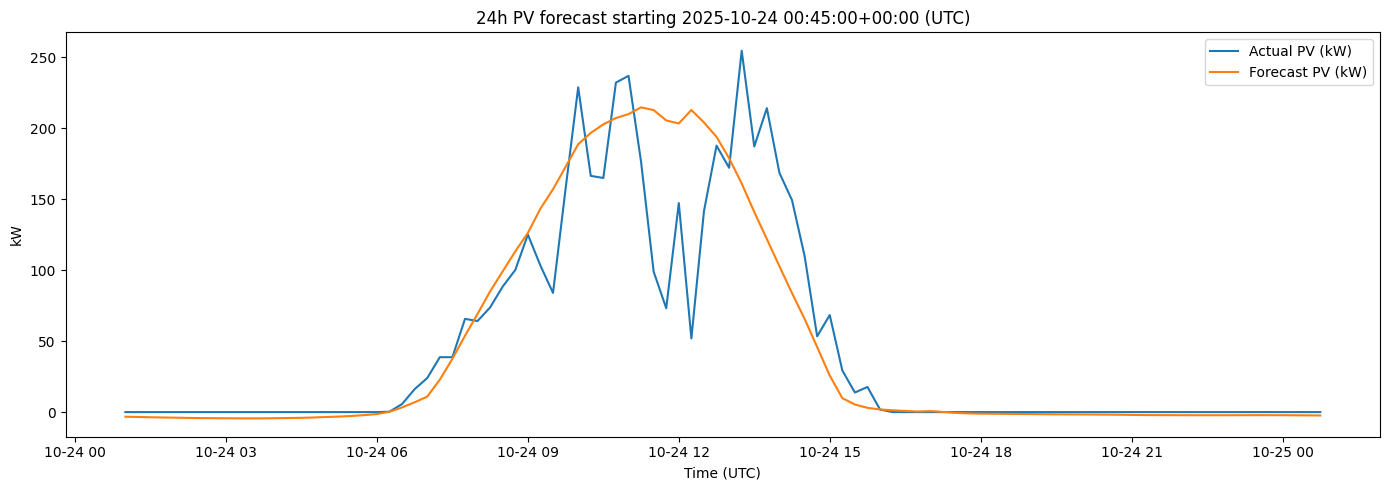

In [16]:
plt.figure(figsize=(14,5))
plt.plot(actual_slice.index, actual_slice.values, label="Actual PV (kW)")
plt.plot(fc.index, fc["pv_forecast_kw"].values, label="Forecast PV (kW)")
plt.title(f"24h PV forecast starting {example_start} (UTC)")
plt.xlabel("Time (UTC)")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
y_roll_true = actual_slice.values
y_roll_pred = fc["pv_forecast_kw"].values

mae24  = mean_absolute_error(y_roll_true, y_roll_pred)
rmse24 = np.sqrt(mean_squared_error(y_roll_true, y_roll_pred))
r2_24  = r2_score(y_roll_true, y_roll_pred)

print(f"24h rollout MAE : {mae24:.3f} kW")
print(f"24h rollout RMSE: {rmse24:.3f} kW")
print(f"24h rollout R²  : {r2_24:.4f}")

24h rollout MAE : 16.635 kW
24h rollout RMSE: 34.090 kW
24h rollout R²  : 0.7718


In [18]:
def rolling_backtest_24h(model, full_fe, test_index, lookback=96, horizon=96, stride="1D"):
    """
    Evaluate 24h rollout forecasts across many start times in the TEST window.
    stride: "1D" (daily), "6H", "3H", etc.
    """
    start_candidates = pd.date_range(
        start=test_index.min() + pd.Timedelta(minutes=15*lookback),
        end=test_index.max() - pd.Timedelta(minutes=15*horizon),
        freq=stride,
        tz="UTC"
    )

    rows = []
    for st in start_candidates:
        if st not in full_fe.index:
            continue

        fc = recursive_forecast_24h(model, full_fe, st, lookback=lookback, horizon=horizon)
        y_true = full_fe.loc[fc.index, "pv_kw"].values
        y_pred = fc["pv_forecast_kw"].values

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)

        rows.append({"start": st, "mae": mae, "rmse": rmse, "r2": r2})

    out = pd.DataFrame(rows)
    return out

full_fe = add_time_features(data.copy())
full_fe[WEATHER_VARS] = full_fe[WEATHER_VARS].interpolate("time").ffill().bfill()

bt = rolling_backtest_24h(model, full_fe, test_fe.index, lookback=LOOKBACK, horizon=HORIZON, stride="1D")

print("Backtest runs:", len(bt))
print(bt[["mae","rmse","r2"]].describe())

print("\nMean scores:")
print("MAE :", bt["mae"].mean())
print("RMSE:", bt["rmse"].mean())
print("R²  :", bt["r2"].mean())


Backtest runs: 89
             mae       rmse         r2
count  89.000000  89.000000  89.000000
mean    8.974735  17.391135   0.050539
std     4.448878   9.010146   2.368911
min     3.182567   5.379028 -15.708145
25%     6.049758  11.240825   0.459451
50%     8.132886  15.493066   0.746413
75%    10.144616  20.409478   0.876555
max    24.891611  53.467271   0.963171

Mean scores:
MAE : 8.974735078377488
RMSE: 17.391135337471322
R²  : 0.05053942739841673


In [19]:
def rolling_backtest_24h_with_preds(model, full_fe, test_index, lookback=96, horizon=96, stride="1D"):
    start_candidates = pd.date_range(
        start=test_index.min() + pd.Timedelta(minutes=15*lookback),
        end=test_index.max() - pd.Timedelta(minutes=15*horizon),
        freq=stride,
        tz="UTC"
    )

    rows = []
    all_true = []
    all_pred = []

    for st in start_candidates:
        if st not in full_fe.index:
            continue

        fc = recursive_forecast_24h(model, full_fe, st, lookback=lookback, horizon=horizon)
        y_true = full_fe.loc[fc.index, "pv_kw"].values
        y_pred = fc["pv_forecast_kw"].values

        all_true.append(y_true)
        all_pred.append(y_pred)

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)

        var_true = np.var(y_true)

        rows.append({"start": st, "mae": mae, "rmse": rmse, "r2": r2, "var_true": var_true})

    bt = pd.DataFrame(rows)

    yT = np.concatenate(all_true)
    yP = np.concatenate(all_pred)

    global_mae  = mean_absolute_error(yT, yP)
    global_rmse = np.sqrt(mean_squared_error(yT, yP))
    global_r2   = r2_score(yT, yP)

    return bt, (global_mae, global_rmse, global_r2)

bt, (g_mae, g_rmse, g_r2) = rolling_backtest_24h_with_preds(
    model, full_fe, test_fe.index, lookback=LOOKBACK, horizon=HORIZON, stride="1D"
)

print("Daily metrics summary:")
print(bt[["mae","rmse","r2","var_true"]].describe())

print("\nGLOBAL (concatenated) metrics:")
print(f"Global MAE : {g_mae:.3f} kW")
print(f"Global RMSE: {g_rmse:.3f} kW")
print(f"Global R²  : {g_r2:.4f}")

print("\nRobust R² (median over days):", float(bt["r2"].median()))

VAR_THRESH = 50.0  
bt_nf = bt[bt["var_true"] > VAR_THRESH].copy()
print("\nDays kept after variance filter:", len(bt_nf), "/", len(bt))
print("Filtered mean R²:", float(bt_nf["r2"].mean()))
print("Filtered median R²:", float(bt_nf["r2"].median()))


Daily metrics summary:
             mae       rmse         r2     var_true
count  89.000000  89.000000  89.000000    89.000000
mean    8.974735  17.391135   0.050539  1542.745141
std     4.448878   9.010146   2.368911  1661.592875
min     3.182567   5.379028 -15.708145    15.785586
25%     6.049758  11.240825   0.459451   300.922021
50%     8.132886  15.493066   0.746413  1083.397959
75%    10.144616  20.409478   0.876555  2024.571318
max    24.891611  53.467271   0.963171  7617.130928

GLOBAL (concatenated) metrics:
Global MAE : 8.975 kW
Global RMSE: 19.563 kW
Global R²  : 0.7749

Robust R² (median over days): 0.7464128476468658

Days kept after variance filter: 84 / 89
Filtered mean R²: 0.5362982079597879
Filtered median R²: 0.75403848035245


In [20]:
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

PV_MODEL_PATH = MODEL_DIR / "pv_lstm_openmeteo.keras"

model.save(PV_MODEL_PATH)
print(f"PV model saved to: {PV_MODEL_PATH}")

PV model saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/pv_lstm_openmeteo.keras


In [21]:
import joblib

SCALER_PATH = MODEL_DIR / "pv_scalers.joblib"

joblib.dump(
    {
        "scaler_seq": scaler_seq,
        "scaler_next": scaler_next,
        "scaler_y": scaler_y,
    },
    SCALER_PATH
)

print(f"PV scalers saved to: {SCALER_PATH}")

PV scalers saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/pv_scalers.joblib


In [22]:
import json

META_PATH = MODEL_DIR / "pv_metadata.json"

meta = {
    "LOOKBACK": LOOKBACK,
    "HORIZON": HORIZON,
    "SEQ_FEATURES": SEQ_FEATURES,
    "NEXT_WEATHER": NEXT_WEATHER,
    "WEATHER_VARS": WEATHER_VARS,
    "TIME_FEATS": TIME_FEATS,
    "TEST_DAYS": TEST_DAYS,
    "location": {
        "lat": LAT,
        "lon": LON,
    },
    "resolution_minutes": 15,
    "target": "PV_TotalProduction_kW",
}

with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print(f"PV metadata saved to: {META_PATH}")

PV metadata saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/pv_metadata.json


In [33]:
# import tensorflow as tf
# import joblib
# import json

# model = tf.keras.models.load_model(PV_MODEL_PATH)

# scalers = joblib.load(SCALER_PATH)
# scaler_seq  = scalers["scaler_seq"]
# scaler_next = scalers["scaler_next"]
# scaler_y    = scalers["scaler_y"]

# with open(META_PATH) as f:
#     meta = json.load(f)

# LOOKBACK = meta["LOOKBACK"]
# SEQ_FEATURES = meta["SEQ_FEATURES"]
# NEXT_WEATHER = meta["NEXT_WEATHER"]

EV Baseline Forecasting (ECC) with LSTM + Open-Meteo
- Target: EV_TotalConsumption_kW (EMOB1 + EMOB2)
- Inputs: past EV + weather + time features (+ PV forecast as exogenous)
- One-step + 24h recursive rollout + rolling daily backtest

A hybrid CNN–LSTM–based electric vehicle charging demand forecasting model operating at 15-minute resolution. The model captures short-term and weekly consumption patterns through convolutional and recurrent layers applied to historical EV load, enriched with lagged and rolling statistics, cyclical time features (time-of-day, day-of-week, seasonality), and optional photovoltaic power as an exogenous input. It performs one-step-ahead prediction and is deployed in recursive mode for 24-hour ahead EV demand forecasting, supporting flexibility assessment and energy community optimization.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)

DATA_DIR = Path("/Users/giannispapias/Desktop/TEF EV 2/ECC2/Data")
MASTER_CSV = DATA_DIR / "ECC_master_PV_EMOB1_EMOB2_15min.csv"

dfm = pd.read_csv(MASTER_CSV)
dfm["Started at"] = pd.to_datetime(dfm["Started at"], utc=True, errors="coerce")
dfm = dfm.dropna(subset=["Started at"]).sort_values("Started at").set_index("Started at")

ev = dfm[["EV_TotalConsumption_kW"]].copy()
ev = ev.dropna(subset=["EV_TotalConsumption_kW"]).rename(columns={"EV_TotalConsumption_kW":"ev_kw"}).sort_index()

print("EV coverage:", ev.index.min(), "->", ev.index.max(), "rows:", len(ev))

start_dt = ev.index.min()
end_dt   = ev.index.max()

weather_ev = get_weather_15min(LAT, LON, start_dt, end_dt, WEATHER_VARS, tz="UTC")
data_ev = ev.join(weather_ev, how="left")

data_ev[WEATHER_VARS] = data_ev[WEATHER_VARS].interpolate("time").ffill().bfill()

data_ev["ev_kw"] = data_ev["ev_kw"].clip(lower=0)

print("Merged EV rows:", len(data_ev), "| Missing EV:", data_ev["ev_kw"].isna().sum())

if "PV_TotalProduction_kW" in dfm.columns:
    pv_meas = dfm[["PV_TotalProduction_kW"]].rename(columns={"PV_TotalProduction_kW":"pv_meas_kw"})
    data_ev = data_ev.join(pv_meas, how="left")
    data_ev["pv_meas_kw"] = data_ev["pv_meas_kw"].interpolate("time").ffill().bfill().clip(lower=0)
    print("Added pv_meas_kw feature")
else:
    data_ev["pv_meas_kw"] = np.nan

TensorFlow: 2.14.0
EV coverage: 2024-09-10 22:00:00+00:00 -> 2026-01-18 22:45:00+00:00 rows: 47524
Merged EV rows: 47524 | Missing EV: 0
Added pv_meas_kw feature


In [30]:
data_ev = data_ev.copy()
data_ev.index = pd.to_datetime(data_ev.index, utc=True, errors="coerce")
data_ev = data_ev[~data_ev.index.isna()].sort_index()
data_ev = data_ev.resample("15min").mean()

data_ev["ev_kw"] = pd.to_numeric(data_ev["ev_kw"], errors="coerce").fillna(0.0).clip(lower=0.0)

USE_PV_AS_FEATURE = False
if USE_PV_AS_FEATURE:
    if "pv_meas_kw" not in data_ev.columns:
        for cand in ["PV_TotalProduction_kW", "pv_kw"]:
            if cand in data_ev.columns:
                data_ev = data_ev.rename(columns={cand: "pv_meas_kw"})
                break
    if "pv_meas_kw" in data_ev.columns:
        data_ev["pv_meas_kw"] = pd.to_numeric(data_ev["pv_meas_kw"], errors="coerce")
        data_ev["pv_meas_kw"] = data_ev["pv_meas_kw"].interpolate("time").ffill().bfill().clip(lower=0.0)
    else:
        print("WARNING: PV feature not found -> disabling USE_PV_AS_FEATURE")
        USE_PV_AS_FEATURE = False

WEATHER_VARS = [
    "shortwave_radiation", "direct_radiation", "diffuse_radiation",
    "cloud_cover", "temperature_2m", "wind_speed_10m",
]
WEATHER_VARS = [v for v in WEATHER_VARS if v in data_ev.columns]
if WEATHER_VARS:
    data_ev[WEATHER_VARS] = data_ev[WEATHER_VARS].apply(pd.to_numeric, errors="coerce")
    data_ev[WEATHER_VARS] = data_ev[WEATHER_VARS].interpolate("time").ffill().bfill()

def add_time_features_ev(df_):
    df_ = df_.copy()
    t = df_.index

    minutes = t.hour * 60 + t.minute
    df_["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
    df_["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))

    doy = t.dayofyear.values
    df_["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df_["doy_cos"] = np.cos(2*np.pi*doy/365.25)

    dow = t.dayofweek.values
    df_["dow_sin"] = np.sin(2*np.pi*dow/7.0)
    df_["dow_cos"] = np.cos(2*np.pi*dow/7.0)
    df_["is_weekend"] = (dow >= 5).astype(float)
    return df_

data_ev = add_time_features_ev(data_ev)

TIME_FEATS = ["tod_sin","tod_cos","doy_sin","doy_cos","dow_sin","dow_cos","is_weekend"]

def add_lag_roll(df_, col="ev_kw"):
    df_ = df_.copy()
    df_["lag_1"]   = df_[col].shift(1)
    df_["lag_4"]   = df_[col].shift(4)
    df_["lag_96"]  = df_[col].shift(96)
    df_["lag_672"] = df_[col].shift(672)  # 7 days

    df_["roll_1h_mean"] = df_[col].rolling(4).mean()
    df_["roll_6h_mean"] = df_[col].rolling(24).mean()
    df_["roll_24h_mean"] = df_[col].rolling(96).mean()
    return df_

data_ev = add_lag_roll(data_ev, "ev_kw")

lag_cols = ["lag_1","lag_4","lag_96","lag_672","roll_1h_mean","roll_6h_mean","roll_24h_mean"]
data_ev[lag_cols] = data_ev[lag_cols].fillna(0.0)

TEST_DAYS = 90
split_ts = data_ev.index.max() - pd.Timedelta(days=TEST_DAYS)
train_ev = data_ev[data_ev.index < split_ts].copy()
test_ev  = data_ev[data_ev.index >= split_ts].copy()

print("Train:", train_ev.index.min(), "->", train_ev.index.max(), len(train_ev))
print("Test :", test_ev.index.min(),  "->", test_ev.index.max(),  len(test_ev))

SEQ_FEATURES = ["ev_kw"] + lag_cols + WEATHER_VARS + TIME_FEATS + (["pv_meas_kw"] if USE_PV_AS_FEATURE else [])
NEXT_EXO     = lag_cols + WEATHER_VARS + TIME_FEATS + (["pv_meas_kw"] if USE_PV_AS_FEATURE else [])

missing = sorted(set(SEQ_FEATURES + NEXT_EXO) - set(train_ev.columns))
if missing:
    raise KeyError(f"Missing columns: {missing}")

scaler_seq  = MinMaxScaler()
scaler_next = MinMaxScaler()
scaler_y    = MinMaxScaler()

train_seq_scaled  = scaler_seq.fit_transform(train_ev[SEQ_FEATURES])
train_next_scaled = scaler_next.fit_transform(train_ev[NEXT_EXO])
train_y_scaled    = scaler_y.fit_transform(train_ev[["ev_kw"]])

test_seq_scaled   = scaler_seq.transform(test_ev[SEQ_FEATURES])
test_next_scaled  = scaler_next.transform(test_ev[NEXT_EXO])
test_y_scaled     = scaler_y.transform(test_ev[["ev_kw"]])

LOOKBACK = 7 * 96  # 672

def make_one_step_dataset(seq_scaled, next_scaled, y_scaled, lookback):
    X_seq, X_next, y = [], [], []
    n = len(seq_scaled)
    for t in range(lookback, n-1):
        X_seq.append(seq_scaled[t-lookback:t, :])
        X_next.append(next_scaled[t+1, :])
        y.append(y_scaled[t+1, :])
    return np.array(X_seq), np.array(X_next), np.array(y)

Xtr_seq, Xtr_next, ytr = make_one_step_dataset(train_seq_scaled, train_next_scaled, train_y_scaled, LOOKBACK)
Xte_seq, Xte_next, yte = make_one_step_dataset(test_seq_scaled,  test_next_scaled,  test_y_scaled,  LOOKBACK)

print("Xtr:", Xtr_seq.shape, Xtr_next.shape, ytr.shape)
print("Xte:", Xte_seq.shape, Xte_next.shape, yte.shape)

Train: 2024-09-10 22:00:00+00:00 -> 2025-10-20 22:30:00+00:00 38883
Test : 2025-10-20 22:45:00+00:00 -> 2026-01-18 22:45:00+00:00 8641
Xtr: (38210, 672, 21) (38210, 20) (38210, 1)
Xte: (7968, 672, 21) (7968, 20) (7968, 1)


In [26]:
# --- Model: CNN+LSTM ---
tf.keras.backend.clear_session()

n_seq = Xtr_seq.shape[-1]
n_next = Xtr_next.shape[-1]

inp_seq = layers.Input(shape=(LOOKBACK, n_seq), name="seq_input")
x = layers.Conv1D(64, kernel_size=5, padding="causal", activation="relu")(inp_seq)
x = layers.Conv1D(64, kernel_size=5, padding="causal", activation="relu")(x)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dropout(0.3)(x)

inp_next = layers.Input(shape=(n_next,), name="next_input")
z = layers.Dense(64, activation="relu")(inp_next)
z = layers.Dropout(0.2)(z)

h = layers.Concatenate()([x, z])
h = layers.Dense(128, activation="relu")(h)
h = layers.Dropout(0.3)(h)
out = layers.Dense(1, name="ev_next")(h)

model = models.Model([inp_seq, inp_next], out)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=tf.keras.losses.Huber(delta=0.5))
model.summary()

es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)

hist = model.fit(
    {"seq_input": Xtr_seq, "next_input": Xtr_next},
    ytr,
    validation_split=0.15,
    epochs=60,
    batch_size=256,
    callbacks=[es, rlr],
    verbose=1
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 seq_input (InputLayer)      [(None, 672, 21)]            0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 672, 64)              6784      ['seq_input[0][0]']           
                                                                                                  
 conv1d_1 (Conv1D)           (None, 672, 64)              20544     ['conv1d[0][0]']              
                                                                                                  
 next_input (InputLayer)     [(None, 20)]                 0         []                            
                                                                                              

In [27]:
print("Model inputs:")
for inp in model.inputs:
    print(inp.name, inp.shape)

print("Xte_seq:", Xte_seq.shape)
print("Xte_next:", Xte_next.shape)

Xte_seq_f  = Xte_seq.astype("float32")
Xte_next_f = Xte_next.astype("float32")

Model inputs:
seq_input (None, 672, 21)
next_input (None, 20)
Xte_seq: (7968, 672, 21)
Xte_next: (7968, 20)


In [28]:
yhat_scaled = model.predict({"seq_input": Xte_seq_f, "next_input": Xte_next_f}, verbose=0)
yhat  = scaler_y.inverse_transform(yhat_scaled).flatten()
ytrue = scaler_y.inverse_transform(yte).flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(ytrue, yhat)
rmse = np.sqrt(mean_squared_error(ytrue, yhat))
r2   = r2_score(ytrue, yhat)

print(f"EV One-step Test MAE : {mae:.3f} kW")
print(f"EV One-step Test RMSE: {rmse:.3f} kW")
print(f"EV One-step Test R²  : {r2:.4f}")

EV One-step Test MAE : 9.183 kW
EV One-step Test RMSE: 14.197 kW
EV One-step Test R²  : 0.9698


In [29]:
HORIZON = 96  # 24h

def recursive_forecast_ev_24h(ev_model, full_df, start_time, lookback=LOOKBACK, horizon=HORIZON):
    if start_time not in full_df.index:
        raise ValueError("start_time not in index")

    idx = full_df.index
    start_pos = idx.get_loc(start_time)
    if start_pos < lookback:
        raise ValueError("Not enough history")

    seq_scaled  = scaler_seq.transform(full_df[SEQ_FEATURES])
    next_scaled = scaler_next.transform(full_df[NEXT_EXO]) 

    preds_scaled = []
    for step in range(1, horizon+1):
        t = start_pos + step - 1

        X_seq  = seq_scaled[t-lookback:t, :].reshape(1, lookback, -1)
        X_next = next_scaled[t+1, :].reshape(1, -1)

        y_next = ev_model.predict({"seq_input": X_seq.astype("float32"),
                                   "next_input": X_next.astype("float32")}, verbose=0)[0,0]
        preds_scaled.append(y_next)

        seq_scaled[t+1, 0] = y_next

    preds_kw = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
    times = idx[start_pos+1:start_pos+1+horizon]
    return pd.DataFrame({"ev_forecast_kw": preds_kw}, index=times)

full_ev = data_ev.copy() 
example_start = test_ev.index[LOOKBACK + 200]
fc = recursive_forecast_ev_24h(model, full_ev, example_start)

y_true = full_ev.loc[fc.index, "ev_kw"].values
y_pred = fc["ev_forecast_kw"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"EV 24h rollout MAE : {mae:.3f} kW")
print(f"EV 24h rollout RMSE: {rmse:.3f} kW")
print(f"EV 24h rollout R²  : {r2:.4f}")

EV 24h rollout MAE : 15.526 kW
EV 24h rollout RMSE: 23.868 kW
EV 24h rollout R²  : 0.8796


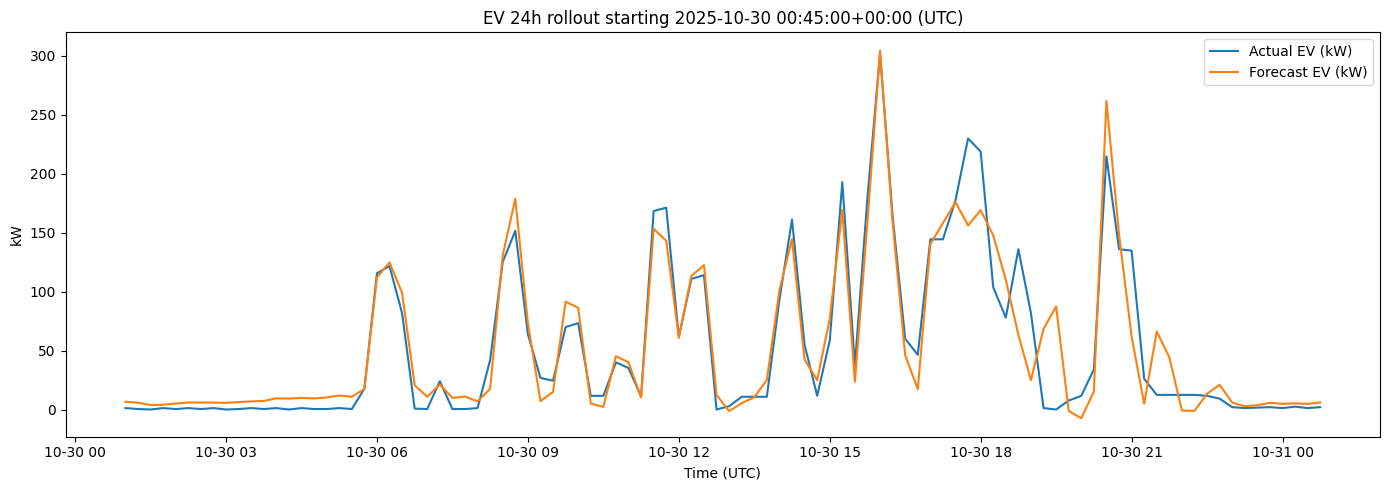

Peak actual: 302.0 kW
Peak pred  : 304.3947 kW


In [30]:
plt.figure(figsize=(14,5))
plt.plot(fc.index, y_true, label="Actual EV (kW)")
plt.plot(fc.index, y_pred, label="Forecast EV (kW)")
plt.title(f"EV 24h rollout starting {example_start} (UTC)")
plt.xlabel("Time (UTC)")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

print("Peak actual:", y_true.max(), "kW")
print("Peak pred  :", y_pred.max(), "kW")

In [31]:
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

EV_MODEL_PATH = MODEL_DIR / "ev_cnn_lstm_baseline.keras"

model.save(EV_MODEL_PATH)
print(f"EV model saved to: {EV_MODEL_PATH}")

EV model saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/ev_cnn_lstm_baseline.keras


In [32]:
import joblib

EV_SCALER_PATH = MODEL_DIR / "ev_scalers.joblib"

joblib.dump(
    {
        "scaler_seq": scaler_seq,
        "scaler_next": scaler_next,
        "scaler_y": scaler_y,
    },
    EV_SCALER_PATH
)

print(f"EV scalers saved to: {EV_SCALER_PATH}")

EV scalers saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/ev_scalers.joblib


In [33]:
import json

EV_META_PATH = MODEL_DIR / "ev_metadata.json"

ev_meta = {
    "model_type": "CNN + LSTM",
    "target": "EV_TotalConsumption_kW",
    "resolution_minutes": 15,

    "LOOKBACK": LOOKBACK,
    "HORIZON": HORIZON,
    "TEST_DAYS": TEST_DAYS,

    "SEQ_FEATURES": SEQ_FEATURES,
    "NEXT_EXO": NEXT_EXO,
    "TIME_FEATS": TIME_FEATS,
    "WEATHER_VARS": WEATHER_VARS,
    "USE_PV_AS_FEATURE": USE_PV_AS_FEATURE,

    "loss": "Huber(delta=0.5)",
    "optimizer": "Adam(1e-3)",

    "notes": "Baseline EV demand forecasting with lag/rolling features and weekly memory"
}

with open(EV_META_PATH, "w") as f:
    json.dump(ev_meta, f, indent=2)

print(f"EV metadata saved to: {EV_META_PATH}")

EV metadata saved to: /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/models/ev_metadata.json


In [44]:
# import tensorflow as tf
# import joblib
# import json

# ev_model = tf.keras.models.load_model(EV_MODEL_PATH)

# scalers = joblib.load(EV_SCALER_PATH)
# scaler_seq  = scalers["scaler_seq"]
# scaler_next = scalers["scaler_next"]
# scaler_y    = scalers["scaler_y"]

# with open(EV_META_PATH) as f:
#     ev_meta = json.load(f)

# LOOKBACK = ev_meta["LOOKBACK"]
# SEQ_FEATURES = ev_meta["SEQ_FEATURES"]
# NEXT_EXO = ev_meta["NEXT_EXO"]

In [34]:
# import sys
# import tensorflow as tf

# print("Python:", sys.version)
# print("TF:", tf.__version__)
# print("GPU:", tf.config.list_physical_devices())

In [31]:
import sys
print(sys.executable)
print(sys.version)

/Users/giannispapias/Desktop/tef_ev-ecc_flexibility/.venv-tf/bin/python
3.11.11 (main, Dec  3 2024, 17:20:40) [Clang 16.0.0 (clang-1600.0.26.4)]


In [32]:
# # %% 
# import numpy as np
import pandas as pd
import joblib, json
from pathlib import Path
import tensorflow as tf

# print("tf:", tf.__version__)

In [ ]:
# %%
DATA_DIR = Path("/Users/giannispapias/Desktop/TEF EV 2/ECC2/Data")
MODEL_DIR = DATA_DIR / "models"

PV_MODEL_PATH = MODEL_DIR / "pv_lstm_openmeteo.keras"
PV_SCALER_PATH = MODEL_DIR / "pv_scalers.joblib"
PV_META_PATH = MODEL_DIR / "pv_metadata.json"

EV_MODEL_PATH = MODEL_DIR / "ev_cnn_lstm_baseline.keras"
EV_SCALER_PATH = MODEL_DIR / "ev_scalers.joblib"
EV_META_PATH = MODEL_DIR / "ev_metadata.json"

pv_model = tf.keras.models.load_model(PV_MODEL_PATH)
pv_scalers = joblib.load(PV_SCALER_PATH)
with open(PV_META_PATH) as f:
    pv_meta = json.load(f)

ev_model = tf.keras.models.load_model(EV_MODEL_PATH)
ev_scalers = joblib.load(EV_SCALER_PATH)
with open(EV_META_PATH) as f:
    ev_meta = json.load(f)

print("Loaded PV model + scalers + meta")
print("Loaded EV model + scalers + meta")

PV_LOOKBACK = int(pv_meta["LOOKBACK"])
PV_HORIZON  = int(pv_meta["HORIZON"])
PV_SEQ_FEATURES = pv_meta["SEQ_FEATURES"]
PV_NEXT_WEATHER = pv_meta["NEXT_WEATHER"]
PV_WEATHER_VARS = pv_meta["WEATHER_VARS"]
PV_TIME_FEATS   = pv_meta["TIME_FEATS"]

pv_scaler_seq  = pv_scalers["scaler_seq"]
pv_scaler_next = pv_scalers["scaler_next"]
pv_scaler_y    = pv_scalers["scaler_y"]

EV_LOOKBACK = int(ev_meta["LOOKBACK"])
EV_HORIZON  = int(ev_meta["HORIZON"])
EV_SEQ_FEATURES = ev_meta["SEQ_FEATURES"]
EV_NEXT_EXO     = ev_meta["NEXT_EXO"]
EV_WEATHER_VARS = ev_meta["WEATHER_VARS"]
EV_TIME_FEATS   = ev_meta["TIME_FEATS"]
USE_PV_AS_FEATURE = bool(ev_meta.get("USE_PV_AS_FEATURE", False))

ev_scaler_seq  = ev_scalers["scaler_seq"]
ev_scaler_next = ev_scalers["scaler_next"]
ev_scaler_y    = ev_scalers["scaler_y"]

print("PV_LOOKBACK:", PV_LOOKBACK, "PV_HORIZON:", PV_HORIZON)
print("EV_LOOKBACK:", EV_LOOKBACK, "EV_HORIZON:", EV_HORIZON, "USE_PV_AS_FEATURE:", USE_PV_AS_FEATURE)

Loaded PV model + scalers + meta
Loaded EV model + scalers + meta
PV_LOOKBACK: 96 PV_HORIZON: 96
EV_LOOKBACK: 672 EV_HORIZON: 96 USE_PV_AS_FEATURE: False


In [ ]:
def add_time_features_pv(df_):
    df_ = df_.copy()
    t = df_.index
    minutes = t.hour * 60 + t.minute
    df_["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
    df_["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))
    doy = t.dayofyear.values
    df_["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df_["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    return df_

def add_time_features_ev(df_):
    df_ = df_.copy()
    t = df_.index
    minutes = t.hour * 60 + t.minute
    df_["tod_sin"] = np.sin(2*np.pi*minutes/(24*60))
    df_["tod_cos"] = np.cos(2*np.pi*minutes/(24*60))
    doy = t.dayofyear.values
    df_["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df_["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    dow = t.dayofweek.values
    df_["dow_sin"] = np.sin(2*np.pi*dow/7.0)
    df_["dow_cos"] = np.cos(2*np.pi*dow/7.0)
    df_["is_weekend"] = (dow >= 5).astype(float)
    return df_

In [ ]:
def pv_recursive_forecast(model, full_fe, start_time, lookback=PV_LOOKBACK, horizon=PV_HORIZON):
    """
    full_fe must contain PV_SEQ_FEATURES and PV_NEXT_WEATHER, indexed in UTC at 15-min.
    Returns pv_forecast_kw for [start_time+1 ... start_time+horizon],
    truncated if there is not enough future data.
    """
    if start_time not in full_fe.index:
        raise ValueError("start_time must exist in full_fe.index")
    idx = full_fe.index
    n = len(idx)
    start_pos = idx.get_loc(start_time)
    if start_pos < lookback:
        raise ValueError("Not enough history before start_time")
    max_horizon = min(horizon, n - 1 - start_pos)
    if max_horizon <= 0:
        raise ValueError("Not enough future steps after start_time for the requested horizon")

    seq_scaled  = pv_scaler_seq.transform(full_fe[PV_SEQ_FEATURES])
    next_scaled = pv_scaler_next.transform(full_fe[PV_NEXT_WEATHER])

    preds_scaled = []
    for step in range(1, max_horizon + 1):
        t = start_pos + step - 1

        X_seq  = seq_scaled[t - lookback + 1:t + 1, :].reshape(1, lookback, -1)
        X_next = next_scaled[t + 1, :].reshape(1, -1)

        y_next_scaled = model.predict({"seq_input": X_seq, "next_input": X_next}, verbose=0)[0, 0]
        preds_scaled.append(y_next_scaled)

        seq_scaled[t + 1, 0] = y_next_scaled

    preds_kw = pv_scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    times = idx[start_pos + 1:start_pos + 1 + max_horizon]
    return pd.Series(preds_kw, index=times, name="pv_forecast_kw")


def ev_recursive_forecast(model, full_fe, start_time, lookback=EV_LOOKBACK, horizon=EV_HORIZON):
    """
    full_fe must contain EV_SEQ_FEATURES and EV_NEXT_EXO, indexed in UTC at 15-min.
    Returns ev_baseline_forecast_kw for [start_time+1 ... start_time+horizon],
    truncated if there is not enough future data.
    """
    if start_time not in full_fe.index:
        raise ValueError("start_time must exist in full_fe.index")
    idx = full_fe.index
    n = len(idx)
    start_pos = idx.get_loc(start_time)
    if start_pos < lookback:
        raise ValueError("Not enough history before start_time")
    max_horizon = min(horizon, n - 1 - start_pos)
    if max_horizon <= 0:
        raise ValueError("Not enough future steps after start_time for the requested horizon")

    seq_scaled  = ev_scaler_seq.transform(full_fe[EV_SEQ_FEATURES])
    next_scaled = ev_scaler_next.transform(full_fe[EV_NEXT_EXO])

    preds_scaled = []
    for step in range(1, max_horizon + 1):
        t = start_pos + step - 1

        X_seq  = seq_scaled[t - lookback:t, :].reshape(1, lookback, -1)
        X_next = next_scaled[t + 1, :].reshape(1, -1)

        y_next_scaled = model.predict(
            {"seq_input": X_seq.astype("float32"), "next_input": X_next.astype("float32")},
            verbose=0
        )[0, 0]
        preds_scaled.append(y_next_scaled)

        seq_scaled[t + 1, 0] = y_next_scaled

    preds_kw = ev_scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    times = idx[start_pos + 1:start_pos + 1 + max_horizon]
    return pd.Series(preds_kw, index=times, name="ev_baseline_forecast_kw")

In [ ]:
import cvxpy as cp

def solve_ecc_mpc(
    pv_fc: pd.Series,
    ev_base_fc: pd.Series,
    dt_hours: float = 0.25,

    u_min: float = -200.0,
    u_max: float =  200.0,

    ev_min: float = 0.0,
    ev_max: float = 800.0,  

    ramp_max: float = 80.0,

    import_cap: float | None = None,
    export_cap: float | None = None,  

    w_import: float = 1.0,
    w_export: float = 2.0,
    w_ramp: float = 0.2,
    w_u: float = 0.01,
    w_cap: float = 5.0,

    enforce_energy_shift: bool = True,

    solver: str = "OSQP",
):
    """
    Decision: u[k] (kW) added to EV baseline.
    Grid exchange: Pgrid = (EV_base + u) - PV
      import:  pos(Pgrid)
      export:  pos(-Pgrid)

    Returns: dict with u*, ev_ctrl*, pgrid*, objective, status.
    """
    pv_fc, ev_base_fc = pv_fc.align(ev_base_fc, join="inner")
    H = len(pv_fc)
    if H == 0:
        raise ValueError("Empty aligned forecast horizon")

    pv = pv_fc.values
    evb = ev_base_fc.values

    u = cp.Variable(H)

    ev_ctrl = evb + u
    pgrid = ev_ctrl - pv

    imp = cp.pos(pgrid)     
    exp = cp.pos(-pgrid)    

    constraints = []
    constraints += [u >= u_min, u <= u_max]
    constraints += [ev_ctrl >= ev_min, ev_ctrl <= ev_max]

    if ramp_max is not None and ramp_max > 0 and H > 1:
        constraints += [cp.abs(u[1:] - u[:-1]) <= ramp_max]

    if enforce_energy_shift:
        constraints += [cp.sum(u) == 0]

    cap_penalties = 0
    if import_cap is not None:
        cap_penalties += cp.sum(cp.pos(imp - import_cap))
    if export_cap is not None:
        cap_penalties += cp.sum(cp.pos(exp - export_cap))

    # Objective: reduce import + export, keep u small and smooth
    obj = (
        w_import * cp.sum(imp) * dt_hours +
        w_export * cp.sum(exp) * dt_hours +
        w_u      * cp.sum_squares(u) +
        w_ramp   * (cp.sum_squares(u[1:] - u[:-1]) if H > 1 else 0) +
        w_cap    * cap_penalties
    )

    problem = cp.Problem(cp.Minimize(obj), constraints)
    problem.solve(solver=solver, verbose=False)

    if problem.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"MPC solve failed: {problem.status}")

    u_star = np.array(u.value).flatten()
    ev_ctrl_star = evb + u_star
    pgrid_star = ev_ctrl_star - pv

    out = {
        "status": problem.status,
        "u_kw": pd.Series(u_star, index=pv_fc.index, name="u_kw"),
        "ev_ctrl_kw": pd.Series(ev_ctrl_star, index=pv_fc.index, name="ev_ctrl_kw"),
        "pgrid_kw": pd.Series(pgrid_star, index=pv_fc.index, name="pgrid_kw"),
        "objective": problem.value,
    }

    imp_star = np.maximum(pgrid_star, 0.0)
    exp_star = np.maximum(-pgrid_star, 0.0)
    out["import_kw"] = pd.Series(imp_star, index=pv_fc.index, name="import_kw")
    out["export_kw"] = pd.Series(exp_star, index=pv_fc.index, name="export_kw")

    return out

In [ ]:
full_pv = data.copy()
full_pv = full_pv.resample("15min").mean()
full_pv["pv_kw"] = pd.to_numeric(full_pv["pv_kw"], errors="coerce").fillna(0.0).clip(lower=0.0)
full_pv[PV_WEATHER_VARS] = full_pv[PV_WEATHER_VARS].interpolate("time").ffill().bfill()
full_pv = add_time_features_pv(full_pv)

full_ev = data_ev.copy()
full_ev = full_ev.resample("15min").mean()
full_ev["ev_kw"] = pd.to_numeric(full_ev["ev_kw"], errors="coerce").fillna(0.0).clip(lower=0.0)
for c in EV_WEATHER_VARS:
    full_ev[c] = pd.to_numeric(full_ev[c], errors="coerce")
full_ev[EV_WEATHER_VARS] = full_ev[EV_WEATHER_VARS].interpolate("time").ffill().bfill()
full_ev = add_time_features_ev(full_ev)

missing_pv = sorted(set(PV_SEQ_FEATURES + PV_NEXT_WEATHER) - set(full_pv.columns))
if missing_pv:
    raise KeyError(f"PV full_fe missing columns: {missing_pv}")

missing_ev = sorted(set(EV_SEQ_FEATURES + EV_NEXT_EXO) - set(full_ev.columns))
if missing_ev:
    raise KeyError(f"EV full_fe missing columns: {missing_ev}")

idx_common = full_pv.index.intersection(full_ev.index).sort_values()
n_common = len(idx_common)
min_lookback = max(PV_LOOKBACK, EV_LOOKBACK)
max_horizon = max(PV_HORIZON, EV_HORIZON)

pos_max = n_common - 1 - max_horizon
if pos_max <= min_lookback:
    raise ValueError("Not enough data to satisfy lookback and horizon around any decision time")

t0 = idx_common[pos_max]
print("Decision time t0:", t0)

pv_fc = pv_recursive_forecast(pv_model, full_pv, t0, lookback=PV_LOOKBACK, horizon=PV_HORIZON)
ev_base_fc = ev_recursive_forecast(ev_model, full_ev, t0, lookback=EV_LOOKBACK, horizon=EV_HORIZON)

mpc = solve_ecc_mpc(
    pv_fc=pv_fc,
    ev_base_fc=ev_base_fc,
    u_min=-200, u_max=200,
    ev_min=0, ev_max=800,
    ramp_max=80,
    import_cap=None,
    export_cap=None,
    w_import=1.0, w_export=2.0, w_ramp=0.2, w_u=0.01, w_cap=5.0,
    enforce_energy_shift=True,
    solver="OSQP",
)

u0 = float(mpc["u_kw"].iloc[0])
print("MPC status:", mpc["status"])
print("Apply now u0 (kW):", u0)

Decision time t0: 2026-01-17 22:45:00+00:00
MPC status: optimal
Apply now u0 (kW): -4.65832952629271


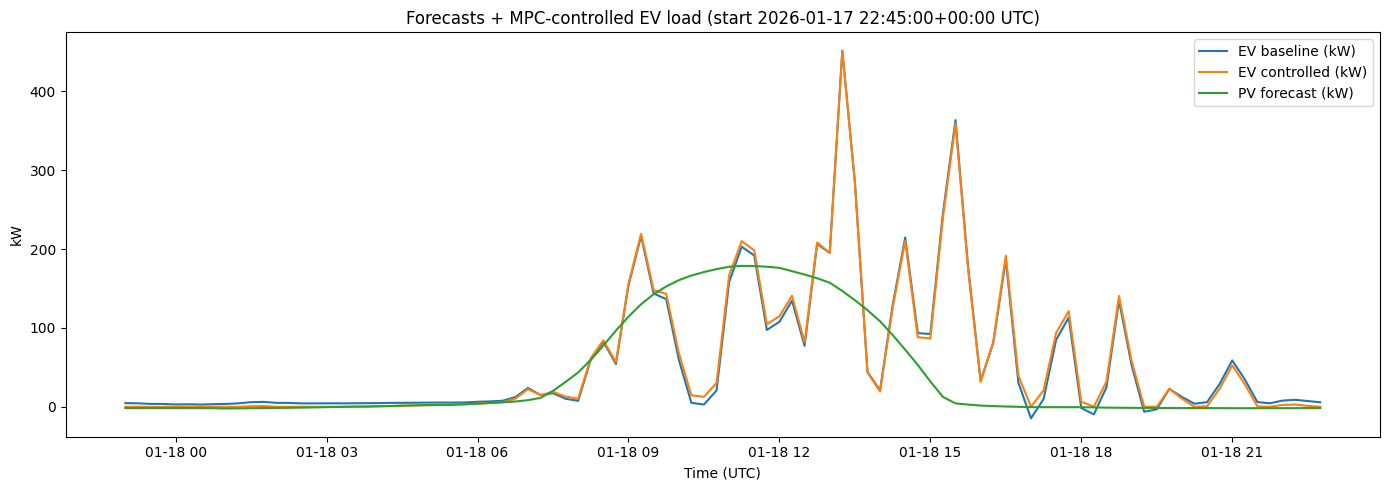

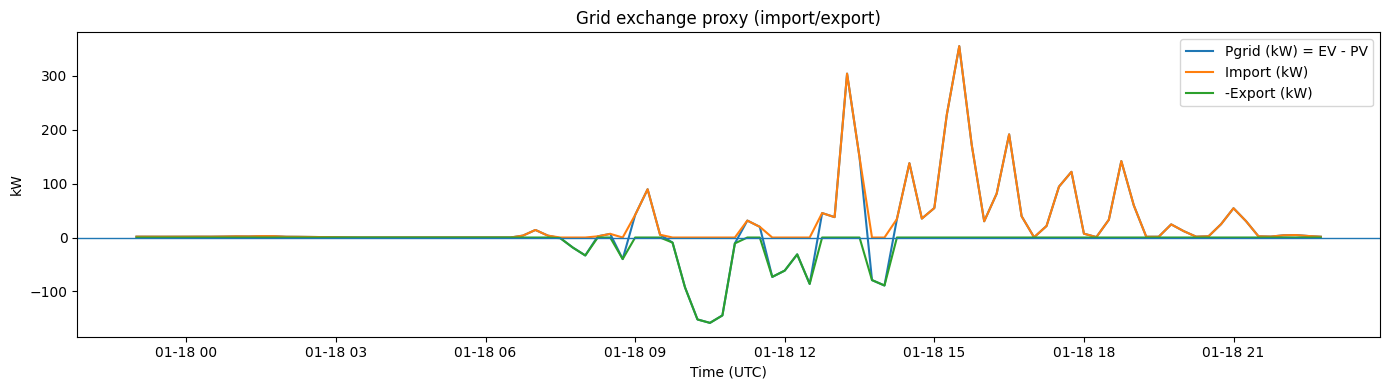

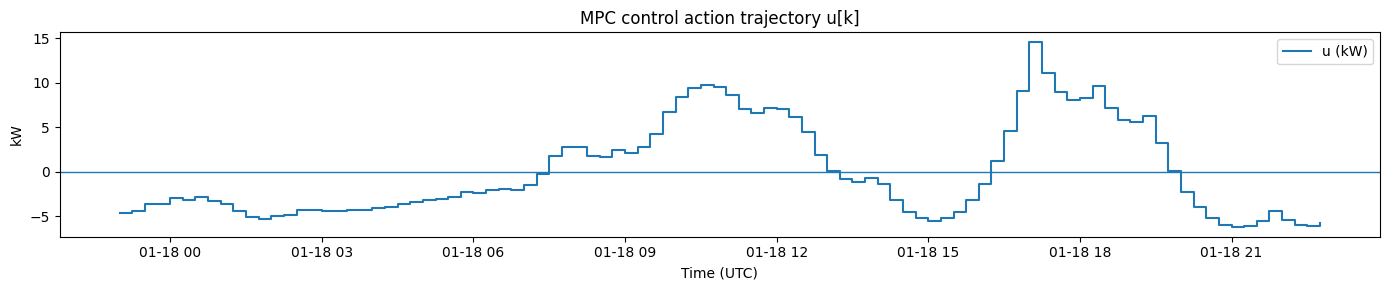

In [ ]:
import matplotlib.pyplot as plt

ts = pv_fc.index
ev_ctrl = mpc["ev_ctrl_kw"]
pgrid = mpc["pgrid_kw"]
imp = mpc["import_kw"]
exp = mpc["export_kw"]

plt.figure(figsize=(14,5))
plt.plot(ts, ev_base_fc.values, label="EV baseline (kW)")
plt.plot(ts, ev_ctrl.values, label="EV controlled (kW)")
plt.plot(ts, pv_fc.values, label="PV forecast (kW)")
plt.title(f"Forecasts + MPC-controlled EV load (start {t0} UTC)")
plt.xlabel("Time (UTC)"); plt.ylabel("kW")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(14,4))
plt.plot(ts, pgrid.values, label="Pgrid (kW) = EV - PV")
plt.plot(ts, imp.values, label="Import (kW)")
plt.plot(ts, -exp.values, label="-Export (kW)")
plt.axhline(0, linewidth=1)
plt.title("Grid exchange proxy (import/export)")
plt.xlabel("Time (UTC)"); plt.ylabel("kW")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(14,3))
plt.step(ts, mpc["u_kw"].values, where="post", label="u (kW)")
plt.axhline(0, linewidth=1)
plt.title("MPC control action trajectory u[k]")
plt.xlabel("Time (UTC)"); plt.ylabel("kW")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd


def rolling_mpc_backtest(
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    full_pv: pd.DataFrame,
    full_ev: pd.DataFrame,
    step="15min",
    horizon=96,
    u_bounds=(-200, 200),
    ev_bounds=(0, 800),
    ramp_max=80,
    weights=dict(w_import=1.0, w_export=2.0, w_ramp=0.2, w_u=0.01, w_cap=5.0),
    enforce_energy_shift=True,
):
    times = pd.date_range(start_time, end_time, freq=step, tz="UTC")
    actions = []
    for t0 in times:
        if (t0 not in full_pv.index) or (t0 not in full_ev.index):
            continue
        if full_pv.index.get_loc(t0) < PV_LOOKBACK:
            continue
        if full_ev.index.get_loc(t0) < EV_LOOKBACK:
            continue

        pv_fc = pv_recursive_forecast(pv_model, full_pv, t0, lookback=PV_LOOKBACK, horizon=horizon)
        ev_base_fc = ev_recursive_forecast(ev_model, full_ev, t0, lookback=EV_LOOKBACK, horizon=horizon)

        mpc = solve_ecc_mpc(
            pv_fc=pv_fc,
            ev_base_fc=ev_base_fc,
            u_min=u_bounds[0],
            u_max=u_bounds[1],
            ev_min=ev_bounds[0],
            ev_max=ev_bounds[1],
            ramp_max=ramp_max,
            import_cap=None,
            export_cap=None,
            enforce_energy_shift=enforce_energy_shift,
            **weights,
        )

        u0 = float(mpc["u_kw"].iloc[0])
        t1 = mpc["u_kw"].index[0]
        ev_base_next = float(ev_base_fc.loc[t1])
        pv_next = float(pv_fc.loc[t1])

        ev_ctrl_next = ev_base_next + u0
        pgrid_next = ev_ctrl_next - pv_next

        actions.append(
            {
                "t0": t0,
                "t1": t1,
                "u0_kw": u0,
                "pv_fc_kw": pv_next,
                "ev_base_fc_kw": ev_base_next,
                "ev_ctrl_kw": ev_ctrl_next,
                "pgrid_kw": pgrid_next,
                "import_kw": max(pgrid_next, 0.0),
                "export_kw": max(-pgrid_next, 0.0),
            }
        )

    return pd.DataFrame(actions).set_index("t0").sort_index()


bt_end = min(full_pv.index.max(), full_ev.index.max()).floor("15min") - pd.Timedelta(minutes=15 * 96)
bt_start = bt_end - pd.Timedelta(days=7)

bt_mpc = rolling_mpc_backtest(
    start_time=bt_start,
    end_time=bt_end,
    full_pv=full_pv,
    full_ev=full_ev,
    horizon=96,
    u_bounds=(-200, 200),
    ev_bounds=(0, 800),
    ramp_max=80,
    weights=dict(w_import=1.0, w_export=2.0, w_ramp=0.2, w_u=0.01, w_cap=5.0),
    enforce_energy_shift=True,
)

print("MPC steps:", len(bt_mpc))
bt_mpc.head()

MPC steps: 673


,t1,u0_kw,pv_fc_kw,ev_base_fc_kw,ev_ctrl_kw,pgrid_kw,import_kw,export_kw
t0,,,,,,,,
2026-01-10 22:45:00+00:00,2026-01-10 23:00:00+00:00,-4.830200,-1.703986,4.830242,0.000042,1.704028,1.704028,0.0
2026-01-10 23:00:00+00:00,2026-01-10 23:15:00+00:00,-4.411659,-1.665216,4.411707,0.000048,1.665264,1.665264,0.0
2026-01-10 23:15:00+00:00,2026-01-10 23:30:00+00:00,-4.188482,-1.615740,4.188479,-0.000003,1.615737,1.615737,0.0
2026-01-10 23:30:00+00:00,2026-01-10 23:45:00+00:00,-4.087186,-1.596481,4.087278,0.000092,1.596573,1.596573,0.0
2026-01-10 23:45:00+00:00,2026-01-11 00:00:00+00:00,-3.968993,-1.595479,3.969117,0.000124,1.595603,1.595603,0.0


In [ ]:
import cvxpy as cp


def synthetic_price_curve(index, base=80.0, peak=220.0, night=30.0, noise_std=0.0, seed=0):
    """Generate a simple day–ahead-like price profile on the given DatetimeIndex.

    Cheaper at night, very expensive at peak hours,
    flat in between to encourage shifting into medium-price / high-PV hours.
    """
    if len(index) == 0:
        return pd.Series([], index=index, name="price_eur_mwh")

    rng = np.random.default_rng(seed)
    hours = index.hour
    price = np.full(len(index), base, dtype=float)

    night_mask = (hours >= 0) & (hours < 6)
    price[night_mask] = night

    peak_mask = ((hours >= 7) & (hours < 10)) | ((hours >= 17) & (hours < 20))
    price[peak_mask] = peak

    if noise_std > 0.0:
        price += rng.normal(0.0, noise_std, size=len(index))

    return pd.Series(price, index=index, name="price_eur_mwh")


# --- Split total EV forecast into the two metering points ---
cap_emob1 = 4 * 300.0  # 4× DC 300 kW
cap_emob2 = 4 * 400.0 + 8 * 22.0  # 4× DC 400 kW + 8× AC 22 kW
share_emob1 = cap_emob1 / (cap_emob1 + cap_emob2)
share_emob2 = 1.0 - share_emob1

ev1_base_fc = share_emob1 * ev_base_fc
ev2_base_fc = share_emob2 * ev_base_fc

price_fc = synthetic_price_curve(pv_fc.index, noise_std=0.0)

def solve_ecc_mpc_two_sites(
    pv_fc: pd.Series,
    ev1_base_fc: pd.Series,
    ev2_base_fc: pd.Series,
    price_fc: pd.Series,
    dt_hours: float = 0.25,
    u_bounds=(-200.0, 200.0),
    ev1_bounds=(0.0, 1200.0),
    ev2_bounds=(0.0, 1800.0),
    ramp_max: float | None = 80.0,
    enforce_energy_shift: bool = True,
    w_import: float = 8.0,
    w_export: float = 2.0,
    w_u: float = 1e-4,
    w_ramp: float = 0.01,
):
    """Price-driven MPC with two EV metering points (EMOB1, EMOB2).

    Objective emphasises using cheap/PV hours and reducing imports
    during high-price hours, while keeping u/ramp penalties small.
    """
    idx = pv_fc.index.intersection(ev1_base_fc.index).intersection(ev2_base_fc.index).intersection(price_fc.index)
    idx = idx.sort_values()
    if len(idx) == 0:
        raise ValueError("No common index between PV, EV1, EV2 and price forecasts.")

    pv = pv_fc.loc[idx].values
    ev1b = ev1_base_fc.loc[idx].values
    ev2b = ev2_base_fc.loc[idx].values
    price = price_fc.loc[idx].values

    n = len(idx)
    u1 = cp.Variable(n)  # flexibility EMOB1
    u2 = cp.Variable(n)  # flexibility EMOB2

    ev1_ctrl = ev1b + u1
    ev2_ctrl = ev2b + u2
    pgrid = ev1_ctrl + ev2_ctrl - pv  # kW

    imp = cp.Variable(n)
    exp = cp.Variable(n)

    constraints = [
        imp >= 0,
        exp >= 0,
        pgrid == imp - exp,
        ev1_ctrl >= ev1_bounds[0],
        ev1_ctrl <= ev1_bounds[1],
        ev2_ctrl >= ev2_bounds[0],
        ev2_ctrl <= ev2_bounds[1],
        u1 >= u_bounds[0],
        u1 <= u_bounds[1],
        u2 >= u_bounds[0],
        u2 <= u_bounds[1],
    ]
    if n > 1 and ramp_max is not None:
        constraints += [
            cp.abs(u1[1:] - u1[:-1]) <= ramp_max,
            cp.abs(u2[1:] - u2[:-1]) <= ramp_max,
        ]
    if enforce_energy_shift:
        constraints += [cp.sum(u1) == 0, cp.sum(u2) == 0]

    energy_import_mwh = imp * dt_hours / 1000.0
    energy_export_mwh = exp * dt_hours / 1000.0

    cost_import = cp.sum(cp.multiply(price, energy_import_mwh))
    revenue_export = cp.sum(cp.multiply(price, energy_export_mwh))

    obj = (
        w_import * cost_import
        - w_export * revenue_export
        + w_u * (cp.sum_squares(u1) + cp.sum_squares(u2))
    )
    if n > 1 and ramp_max is not None:
        obj += w_ramp * (cp.sum_squares(u1[1:] - u1[:-1]) + cp.sum_squares(u2[1:] - u2[:-1]))

    prob = cp.Problem(cp.Minimize(obj), constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        print("Warning: MPC two-site problem status:", prob.status)

    u1_kw = pd.Series(u1.value, index=idx, name="u1_kw")
    u2_kw = pd.Series(u2.value, index=idx, name="u2_kw")
    ev1_ctrl_kw = pd.Series(ev1_ctrl.value, index=idx, name="ev1_ctrl_kw")
    ev2_ctrl_kw = pd.Series(ev2_ctrl.value, index=idx, name="ev2_ctrl_kw")
    pgrid_kw = pd.Series(pgrid.value, index=idx, name="pgrid_kw")
    import_kw = pd.Series(imp.value, index=idx, name="import_kw")
    export_kw = pd.Series(exp.value, index=idx, name="export_kw")

    res = {
        "u1_kw": u1_kw,
        "u2_kw": u2_kw,
        "ev1_ctrl_kw": ev1_ctrl_kw,
        "ev2_ctrl_kw": ev2_ctrl_kw,
        "pgrid_kw": pgrid_kw,
        "import_kw": import_kw,
        "export_kw": export_kw,
        "price_eur_mwh": price_fc.loc[idx],
        "status": prob.status,
    }

    n_emob1 = 4  # 4 DC 300 kW
    n_emob2_dc = 4
    n_emob2_ac = 8
    res["emob1_per_charger_kw"] = ev1_ctrl_kw / n_emob1
    res["emob2_dc_per_charger_kw"] = ev2_ctrl_kw * 0.5 / n_emob2_dc
    res["emob2_ac_per_charger_kw"] = ev2_ctrl_kw * 0.5 / n_emob2_ac

    return res

mpc_two_sites = solve_ecc_mpc_two_sites(pv_fc, ev1_base_fc, ev2_base_fc, price_fc)
mpc_two_sites["status"]

'optimal'

Baseline cost:      48.53 EUR
Optimized cost:      6.17 EUR
Savings:            42.36 EUR


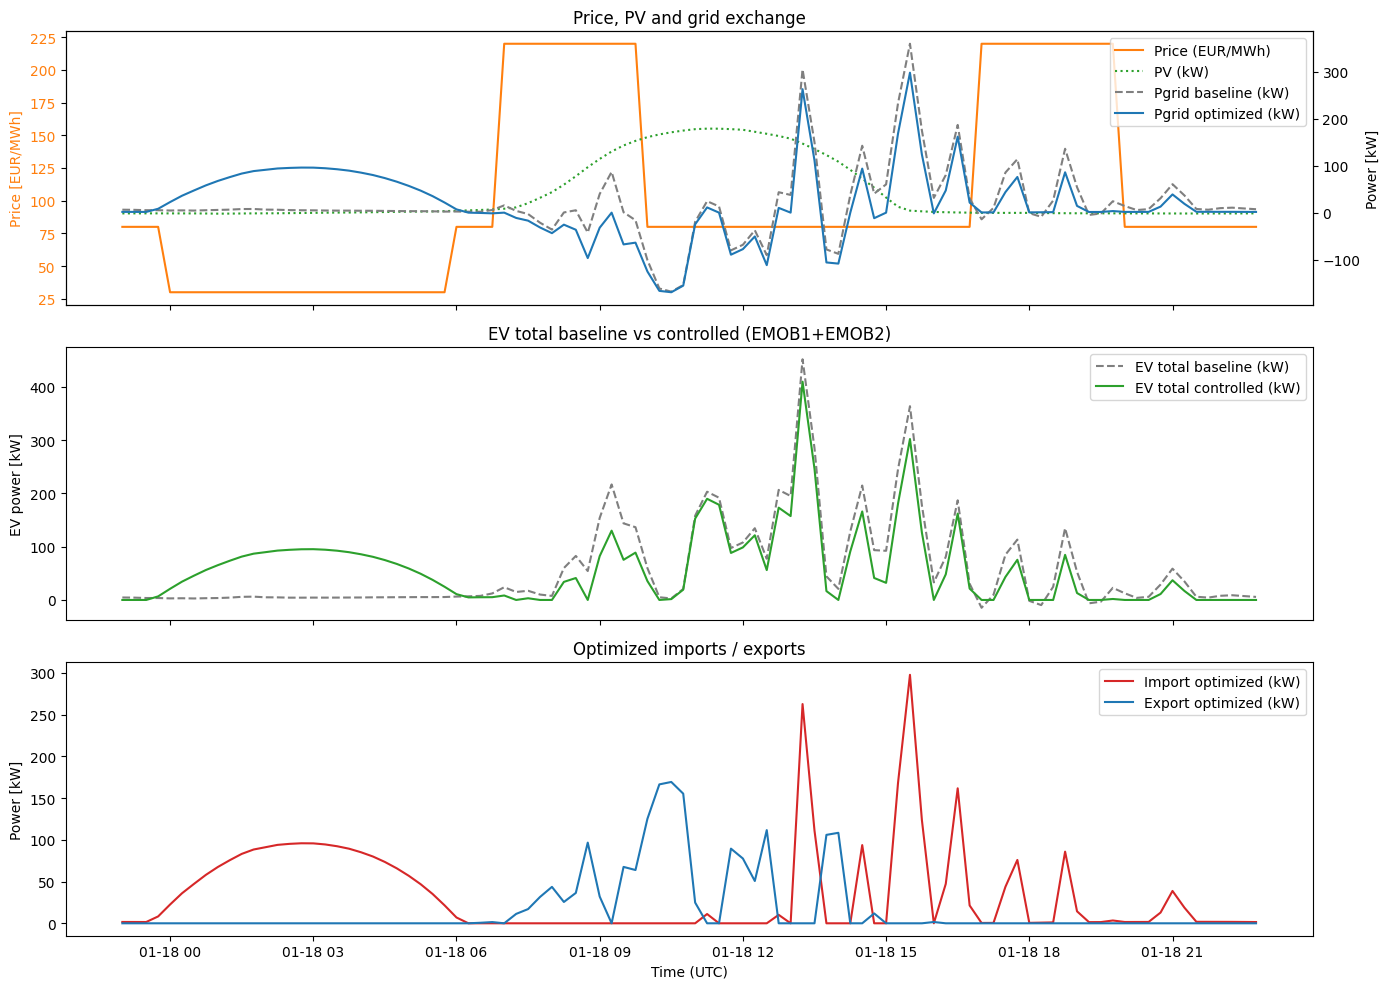

In [ ]:
ts = mpc_two_sites["pgrid_kw"].index
price = mpc_two_sites["price_eur_mwh"]
ev1_ctrl = mpc_two_sites["ev1_ctrl_kw"]
ev2_ctrl = mpc_two_sites["ev2_ctrl_kw"]
ev_total_ctrl = ev1_ctrl + ev2_ctrl

ev_total_base = ev_base_fc.loc[ts]

pv_slice = pv_fc.loc[ts]
pgrid_opt = mpc_two_sites["pgrid_kw"]
imp_opt = mpc_two_sites["import_kw"]
exp_opt = mpc_two_sites["export_kw"]

pgrid_base = ev_total_base - pv_slice
imp_base = pgrid_base.clip(lower=0.0)
exp_base = (-pgrid_base).clip(lower=0.0)

dt_hours = 0.25  
energy_import_opt_mwh = imp_opt * dt_hours / 1000.0
energy_export_opt_mwh = exp_opt * dt_hours / 1000.0
energy_import_base_mwh = imp_base * dt_hours / 1000.0
energy_export_base_mwh = exp_base * dt_hours / 1000.0

cost_opt = (energy_import_opt_mwh * price).sum() - (energy_export_opt_mwh * price).sum()
cost_base = (energy_import_base_mwh * price).sum() - (energy_export_base_mwh * price).sum()
savings = cost_base - cost_opt

print(f"Baseline cost:   {cost_base:8.2f} EUR")
print(f"Optimized cost:  {cost_opt:8.2f} EUR")
print(f"Savings:         {savings:8.2f} EUR")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price, PV and grid power
ax0 = axes[0]
ax0_2 = ax0.twinx()
ax0.plot(ts, price, color="tab:orange", label="Price (EUR/MWh)")
ax0.set_ylabel("Price [EUR/MWh]", color="tab:orange")
ax0.tick_params(axis="y", labelcolor="tab:orange")
ax0_2.plot(ts, pv_slice, color="tab:green", linestyle=":", label="PV (kW)")
ax0_2.plot(ts, pgrid_base, color="tab:gray", linestyle="--", label="Pgrid baseline (kW)")
ax0_2.plot(ts, pgrid_opt, color="tab:blue", label="Pgrid optimized (kW)")
ax0_2.set_ylabel("Power [kW]")
lines, labels = ax0.get_legend_handles_labels()
lines2, labels2 = ax0_2.get_legend_handles_labels()
ax0_2.legend(lines + lines2, labels + labels2, loc="upper right")
ax0.set_title("Price, PV and grid exchange")

# EV power baseline vs controlled
ax1 = axes[1]
ax1.plot(ts, ev_total_base, label="EV total baseline (kW)", color="tab:gray", linestyle="--")
ax1.plot(ts, ev_total_ctrl, label="EV total controlled (kW)", color="tab:green")
ax1.set_ylabel("EV power [kW]")
ax1.legend()
ax1.set_title("EV total baseline vs controlled (EMOB1+EMOB2)")

# Imports and exports (optimized)
ax2 = axes[2]
ax2.plot(ts, imp_opt, label="Import optimized (kW)", color="tab:red")
ax2.plot(ts, exp_opt, label="Export optimized (kW)", color="tab:blue")
ax2.set_ylabel("Power [kW]")
ax2.set_xlabel("Time (UTC)")
ax2.legend()
ax2.set_title("Optimized imports / exports")

plt.tight_layout()
plt.show()

In [ ]:
dt = dt_hours if "dt_hours" in globals() else 0.25
energy_balance_mwh = float((mpc_two_sites["u1_kw"].sum() + mpc_two_sites["u2_kw"].sum()) * dt / 1000.0)
print(f"Energy balance (sum u1+u2) [MWh]: {energy_balance_mwh:.4f}")

print("\nImported energy [MWh]:")
print(f"  Baseline : {energy_import_base_mwh.sum():.4f}")
print(f"  Optimized: {energy_import_opt_mwh.sum():.4f}")

avg_price_import_base = float((energy_import_base_mwh * price).sum() / energy_import_base_mwh.sum())
avg_price_import_opt = float((energy_import_opt_mwh * price).sum() / energy_import_opt_mwh.sum())
print("\nAverage import price [EUR/MWh]:")
print(f"  Baseline : {avg_price_import_base:.2f}")
print(f"  Optimized: {avg_price_import_opt:.2f}")

Energy balance (sum u1+u2) [MWh]: -0.0000

Imported energy [MWh]:
  Baseline : 0.7259
  Optimized: 0.8333

Average import price [EUR/MWh]:
  Baseline : 107.02
  Optimized: 64.27


In [ ]:
# Import cap on the same horizon used for forecasts
dt_hours = 0.25
ts_cap = pv_fc.index.intersection(ev_base_fc.index).sort_values()
pv_slice_cap = pv_fc.loc[ts_cap]
ev_total_base_cap = ev_base_fc.loc[ts_cap]
pgrid_base_cap = ev_total_base_cap - pv_slice_cap
imp_base_cap = pgrid_base_cap.clip(lower=0.0)
import_cap_mwh = float((imp_base_cap * dt_hours / 1000.0).sum())
print(f"Baseline imported energy cap: {import_cap_mwh:.4f} MWh")

def solve_ecc_mpc_two_sites_import_capped(
    pv_fc: pd.Series,
    ev1_base_fc: pd.Series,
    ev2_base_fc: pd.Series,
    price_fc: pd.Series,
    import_mwh_cap: float | None,
    dt_hours: float = 0.25,
    u_bounds=(-200.0, 200.0),
    ev1_bounds=(0.0, 1200.0),
    ev2_bounds=(0.0, 1800.0),
    ramp_max: float | None = 80.0,
    enforce_energy_shift: bool = True,
    w_import: float = 8.0,
    w_export: float = 2.0,
    w_u: float = 1e-3,
    w_ramp: float = 0.05,
):
    """Two-site MPC with price signal and a cap on total imported energy (MWh)."""
    idx = pv_fc.index.intersection(ev1_base_fc.index).intersection(ev2_base_fc.index).intersection(price_fc.index)
    idx = idx.sort_values()
    if len(idx) == 0:
        raise ValueError("No common index between PV, EV1, EV2 and price forecasts.")

    pv = pv_fc.loc[idx].values
    ev1b = ev1_base_fc.loc[idx].values
    ev2b = ev2_base_fc.loc[idx].values
    price = price_fc.loc[idx].values

    n = len(idx)
    u1 = cp.Variable(n)
    u2 = cp.Variable(n)

    ev1_ctrl = ev1b + u1
    ev2_ctrl = ev2b + u2
    pgrid = ev1_ctrl + ev2_ctrl - pv

    imp = cp.Variable(n)
    exp = cp.Variable(n)

    constraints = [
        imp >= 0,
        exp >= 0,
        pgrid == imp - exp,
        ev1_ctrl >= ev1_bounds[0],
        ev1_ctrl <= ev1_bounds[1],
        ev2_ctrl >= ev2_bounds[0],
        ev2_ctrl <= ev2_bounds[1],
        u1 >= u_bounds[0],
        u1 <= u_bounds[1],
        u2 >= u_bounds[0],
        u2 <= u_bounds[1],
    ]
    if n > 1 and ramp_max is not None:
        constraints += [
            cp.abs(u1[1:] - u1[:-1]) <= ramp_max,
            cp.abs(u2[1:] - u2[:-1]) <= ramp_max,
        ]
    if enforce_energy_shift:
        constraints += [cp.sum(u1) == 0, cp.sum(u2) == 0]

    energy_import_mwh = imp * dt_hours / 1000.0
    energy_export_mwh = exp * dt_hours / 1000.0

    if import_mwh_cap is not None:
        constraints += [cp.sum(energy_import_mwh) <= import_mwh_cap]

    cost_import = cp.sum(cp.multiply(price, energy_import_mwh))
    revenue_export = cp.sum(cp.multiply(price, energy_export_mwh))

    obj = (
        w_import * cost_import
        - w_export * revenue_export
        + w_u * (cp.sum_squares(u1) + cp.sum_squares(u2))
    )
    if n > 1 and ramp_max is not None:
        obj += w_ramp * (cp.sum_squares(u1[1:] - u1[:-1]) + cp.sum_squares(u2[1:] - u2[:-1]))

    prob = cp.Problem(cp.Minimize(obj), constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        print("Warning: MPC capped problem status:", prob.status)

    u1_kw = pd.Series(u1.value, index=idx, name="u1_kw")
    u2_kw = pd.Series(u2.value, index=idx, name="u2_kw")
    ev1_ctrl_kw = pd.Series(ev1_ctrl.value, index=idx, name="ev1_ctrl_kw")
    ev2_ctrl_kw = pd.Series(ev2_ctrl.value, index=idx, name="ev2_ctrl_kw")
    pgrid_kw = pd.Series(pgrid.value, index=idx, name="pgrid_kw")
    import_kw = pd.Series(imp.value, index=idx, name="import_kw")
    export_kw = pd.Series(exp.value, index=idx, name="export_kw")

    return {
        "u1_kw": u1_kw,
        "u2_kw": u2_kw,
        "ev1_ctrl_kw": ev1_ctrl_kw,
        "ev2_ctrl_kw": ev2_ctrl_kw,
        "pgrid_kw": pgrid_kw,
        "import_kw": import_kw,
        "export_kw": export_kw,
        "price_eur_mwh": price_fc.loc[idx],
        "status": prob.status,
    }

mpc_two_sites_capped = solve_ecc_mpc_two_sites_import_capped(
    pv_fc, ev1_base_fc, ev2_base_fc, price_fc, import_mwh_cap=import_cap_mwh, dt_hours=dt_hours,
 )
print("Capped MPC status:", mpc_two_sites_capped["status"])

Baseline imported energy cap: 0.7259 MWh
Capped MPC status: optimal


=== Imported energy [MWh] over ts_cmp ===
Baseline : 0.7259
Uncapped : 0.8333

=== Cost [EUR] over ts_cmp ===
Baseline :    48.53
Uncapped :     6.17

=== Average import price [EUR/MWh] over ts_cmp ===
Baseline : 107.02
Uncapped :  64.27

=== On capped horizon ts_cap_cmp ===
Imported energy baseline : 0.7259 MWh
Imported energy capped    : 0.7259 MWh
Cost baseline             :    48.53 EUR
Cost capped               :    39.60 EUR
Avg import price capped   :  97.26 EUR/MWh


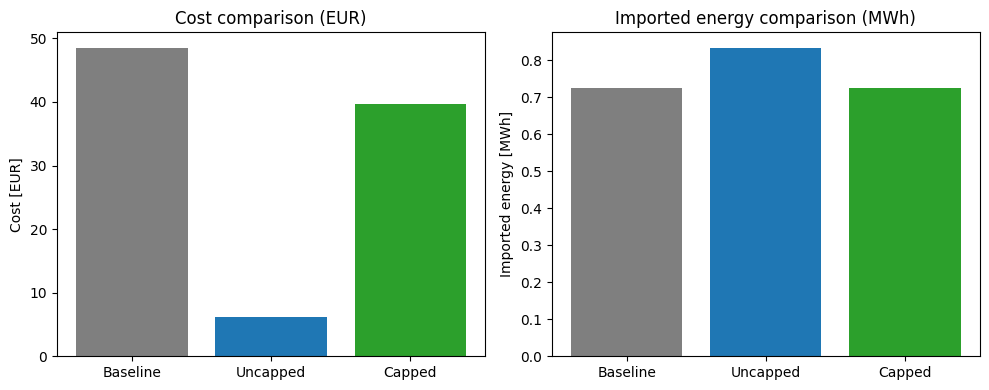

In [ ]:
ts_cmp = mpc_two_sites["pgrid_kw"].index
price_cmp = price_fc.loc[ts_cmp]

pv_cmp = pv_fc.loc[ts_cmp]
ev_base_cmp = ev_base_fc.loc[ts_cmp]
pgrid_base_cmp = ev_base_cmp - pv_cmp
imp_base_cmp = pgrid_base_cmp.clip(lower=0.0)
exp_base_cmp = (-pgrid_base_cmp).clip(lower=0.0)

dt = 0.25  
e_imp_base = imp_base_cmp * dt / 1000.0
e_exp_base = exp_base_cmp * dt / 1000.0
cost_base_cmp = (e_imp_base * price_cmp).sum() - (e_exp_base * price_cmp).sum()
avg_price_imp_base = float((e_imp_base * price_cmp).sum() / e_imp_base.sum())

imp_unc = mpc_two_sites["import_kw"].loc[ts_cmp]
exp_unc = mpc_two_sites["export_kw"].loc[ts_cmp]
e_imp_unc = imp_unc * dt / 1000.0
e_exp_unc = exp_unc * dt / 1000.0
cost_unc = (e_imp_unc * price_cmp).sum() - (e_exp_unc * price_cmp).sum()
avg_price_imp_unc = float((e_imp_unc * price_cmp).sum() / e_imp_unc.sum())

ts_cap_cmp = mpc_two_sites_capped["pgrid_kw"].index.intersection(ts_cmp)
price_cap = price_fc.loc[ts_cap_cmp]
imp_cap = mpc_two_sites_capped["import_kw"].loc[ts_cap_cmp]
exp_cap = mpc_two_sites_capped["export_kw"].loc[ts_cap_cmp]

pv_cap = pv_fc.loc[ts_cap_cmp]
ev_base_cap2 = ev_base_fc.loc[ts_cap_cmp]
pgrid_base_cap2 = ev_base_cap2 - pv_cap
imp_base_cap2 = pgrid_base_cap2.clip(lower=0.0)
exp_base_cap2 = (-pgrid_base_cap2).clip(lower=0.0)

e_imp_cap = imp_cap * dt / 1000.0
e_exp_cap = exp_cap * dt / 1000.0
e_imp_base_cap2 = imp_base_cap2 * dt / 1000.0
e_exp_base_cap2 = exp_base_cap2 * dt / 1000.0

cost_cap = (e_imp_cap * price_cap).sum() - (e_exp_cap * price_cap).sum()
cost_base_cap2 = (e_imp_base_cap2 * price_cap).sum() - (e_exp_base_cap2 * price_cap).sum()
avg_price_imp_cap = float((e_imp_cap * price_cap).sum() / e_imp_cap.sum())

print("=== Imported energy [MWh] over ts_cmp ===")
print(f"Baseline : {e_imp_base.sum():.4f}")
print(f"Uncapped : {e_imp_unc.sum():.4f}")

print("\n=== Cost [EUR] over ts_cmp ===")
print(f"Baseline : {cost_base_cmp:8.2f}")
print(f"Uncapped : {cost_unc:8.2f}")

print("\n=== Average import price [EUR/MWh] over ts_cmp ===")
print(f"Baseline : {avg_price_imp_base:6.2f}")
print(f"Uncapped : {avg_price_imp_unc:6.2f}")

print("\n=== On capped horizon ts_cap_cmp ===")
print(f"Imported energy baseline : {e_imp_base_cap2.sum():.4f} MWh")
print(f"Imported energy capped    : {e_imp_cap.sum():.4f} MWh")
print(f"Cost baseline             : {cost_base_cap2:8.2f} EUR")
print(f"Cost capped               : {cost_cap:8.2f} EUR")
print(f"Avg import price capped   : {avg_price_imp_cap:6.2f} EUR/MWh")

scenarios = ["Baseline", "Uncapped", "Capped"]
costs = [cost_base_cmp, cost_unc, cost_cap]
imports = [e_imp_base.sum(), e_imp_unc.sum(), e_imp_cap.sum()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(scenarios, costs, color=["tab:gray", "tab:blue", "tab:green"])
axes[0].set_title("Cost comparison (EUR)")
axes[0].set_ylabel("Cost [EUR]")

axes[1].bar(scenarios, imports, color=["tab:gray", "tab:blue", "tab:green"])
axes[1].set_title("Imported energy comparison (MWh)")
axes[1].set_ylabel("Imported energy [MWh]")

plt.tight_layout()
plt.show()

Baseline cost (capped horizon):    48.53 EUR
Capped cost (capped horizon):       39.60 EUR


,KPI,Baseline,Capped,Delta
0,Cost (EUR),48.528949,39.604468,-8.924481e+00
1,Imported energy (MWh),0.725857,0.725857,3.359694e-09
2,Avg import price (EUR/MWh),107.017433,97.259065,-9.758369e+00


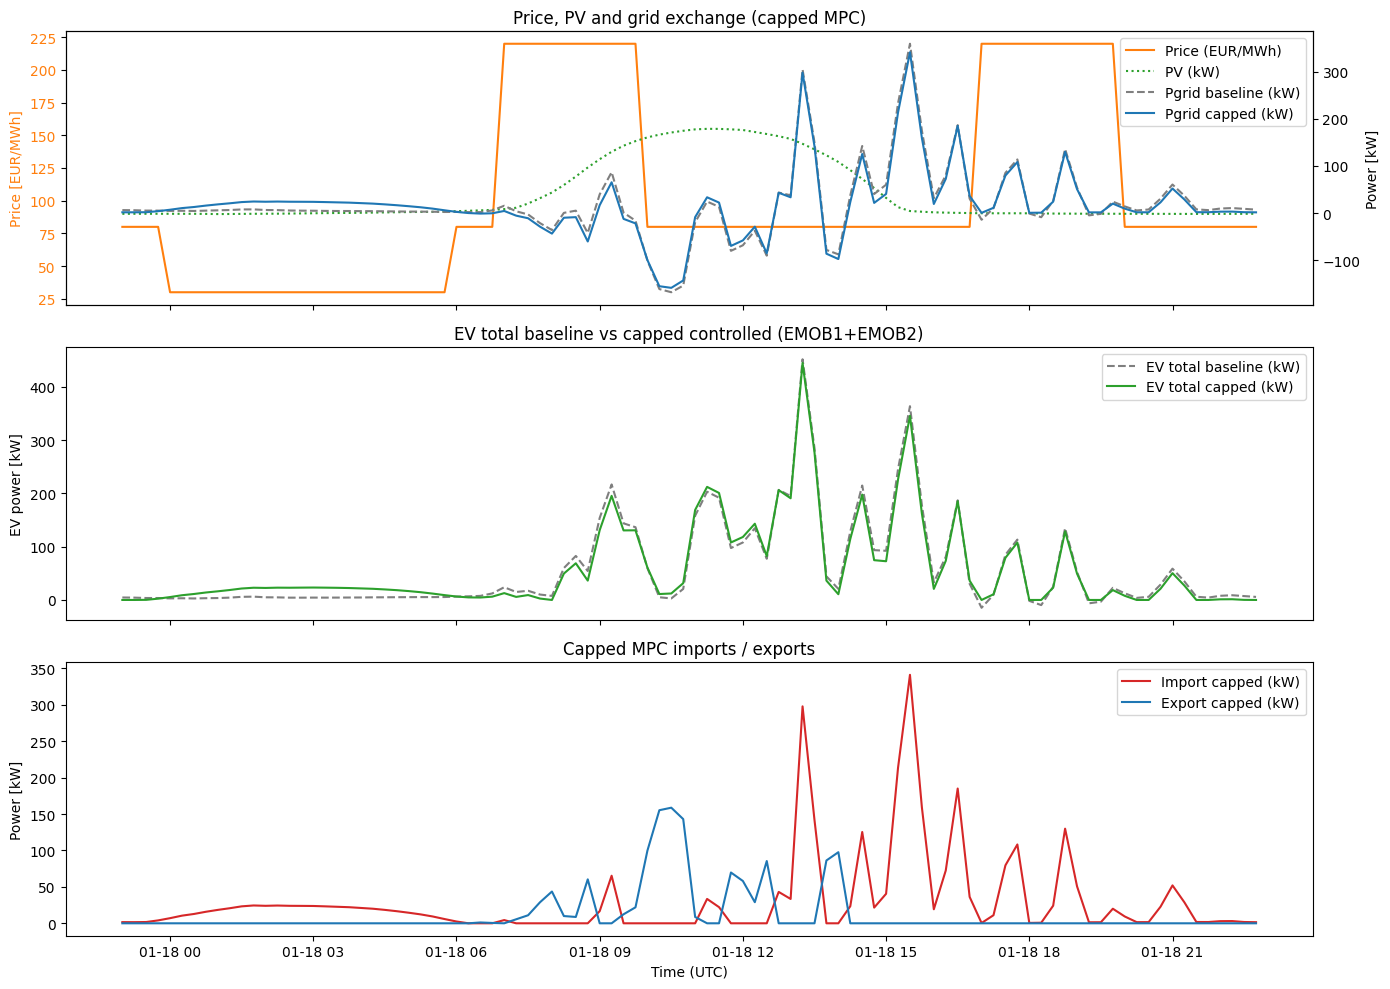

In [ ]:
ts_cap = mpc_two_sites_capped["pgrid_kw"].index
price_cap = mpc_two_sites_capped["price_eur_mwh"]
ev1_ctrl_cap = mpc_two_sites_capped["ev1_ctrl_kw"]
ev2_ctrl_cap = mpc_two_sites_capped["ev2_ctrl_kw"]
ev_total_ctrl_cap = ev1_ctrl_cap + ev2_ctrl_cap

ev_total_base_cap = ev_base_fc.loc[ts_cap]

pv_cap2 = pv_fc.loc[ts_cap]
pgrid_cap = mpc_two_sites_capped["pgrid_kw"]
imp_cap = mpc_two_sites_capped["import_kw"]
exp_cap = mpc_two_sites_capped["export_kw"]

pgrid_base_cap = ev_total_base_cap - pv_cap2
imp_base_cap = pgrid_base_cap.clip(lower=0.0)
exp_base_cap = (-pgrid_base_cap).clip(lower=0.0)

dt = 0.25  
e_imp_base_cap = imp_base_cap * dt / 1000.0
e_exp_base_cap = exp_base_cap * dt / 1000.0
e_imp_cap = imp_cap * dt / 1000.0
e_exp_cap = exp_cap * dt / 1000.0

cost_base_cap = (e_imp_base_cap * price_cap).sum() - (e_exp_base_cap * price_cap).sum()
cost_capped = (e_imp_cap * price_cap).sum() - (e_exp_cap * price_cap).sum()

avg_price_imp_base_cap = float((e_imp_base_cap * price_cap).sum() / e_imp_base_cap.sum())
avg_price_imp_capped = float((e_imp_cap * price_cap).sum() / e_imp_cap.sum())

print("Baseline cost (capped horizon):", f"{cost_base_cap:8.2f} EUR")
print("Capped cost (capped horizon):   ", f"{cost_capped:8.2f} EUR")

kpi_rows = ["Cost (EUR)", "Imported energy (MWh)", "Avg import price (EUR/MWh)"]
baseline_vals = [cost_base_cap, e_imp_base_cap.sum(), avg_price_imp_base_cap]
capped_vals = [cost_capped, e_imp_cap.sum(), avg_price_imp_capped]
delta_vals = [capped_vals[i] - baseline_vals[i] for i in range(len(kpi_rows))]
kpi_cap_df = pd.DataFrame({
    "KPI": kpi_rows,
    "Baseline": baseline_vals,
    "Capped": capped_vals,
    "Delta": delta_vals,
})
display(kpi_cap_df)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price, PV and grid power (baseline vs capped)
ax0 = axes[0]
ax0_2 = ax0.twinx()
ax0.plot(ts_cap, price_cap, color="tab:orange", label="Price (EUR/MWh)")
ax0.set_ylabel("Price [EUR/MWh]", color="tab:orange")
ax0.tick_params(axis="y", labelcolor="tab:orange")
ax0_2.plot(ts_cap, pv_cap2, color="tab:green", linestyle=":", label="PV (kW)")
ax0_2.plot(ts_cap, pgrid_base_cap, color="tab:gray", linestyle="--", label="Pgrid baseline (kW)")
ax0_2.plot(ts_cap, pgrid_cap, color="tab:blue", label="Pgrid capped (kW)")
ax0_2.set_ylabel("Power [kW]")
lines, labels = ax0.get_legend_handles_labels()
lines2, labels2 = ax0_2.get_legend_handles_labels()
ax0_2.legend(lines + lines2, labels + labels2, loc="upper right")
ax0.set_title("Price, PV and grid exchange (capped MPC)")

# EV total baseline vs capped controlled
ax1 = axes[1]
ax1.plot(ts_cap, ev_total_base_cap, label="EV total baseline (kW)", color="tab:gray", linestyle="--")
ax1.plot(ts_cap, ev_total_ctrl_cap, label="EV total capped (kW)", color="tab:green")
ax1.set_ylabel("EV power [kW]")
ax1.legend()
ax1.set_title("EV total baseline vs capped controlled (EMOB1+EMOB2)")

# Imports and exports (capped)
ax2 = axes[2]
ax2.plot(ts_cap, imp_cap, label="Import capped (kW)", color="tab:red")
ax2.plot(ts_cap, exp_cap, label="Export capped (kW)", color="tab:blue")
ax2.set_ylabel("Power [kW]")
ax2.set_xlabel("Time (UTC)")
ax2.legend()
ax2.set_title("Capped MPC imports / exports")

plt.tight_layout()
plt.show()